# LOADING 

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt


In [2]:
columns = [
    'timestamp',

    'activity_id',

    'heart_rate',

    # IMU hand
    'imu_hand_temperature',
    'imu_hand_accel_16_x',
    'imu_hand_accel_16_y',
    'imu_hand_accel_16_z',
    'imu_hand_accel_6_x',
    'imu_hand_accel_6_y',
    'imu_hand_accel_6_z',
    'imu_hand_gyro_x',
    'imu_hand_gyro_y',
    'imu_hand_gyro_z',
    'imu_hand_magnet_x',
    'imu_hand_magnet_y',
    'imu_hand_magnet_z',
    'imu_hand_orientation_1',
    'imu_hand_orientation_2',
    'imu_hand_orientation_3',
    'imu_hand_orientation_4',

    # IMU chest
    'imu_chest_temperature',
    'imu_chest_accel_16_x',
    'imu_chest_accel_16_y',
    'imu_chest_accel_16_z',
    'imu_chest_accel_6_x',
    'imu_chest_accel_6_y',
    'imu_chest_accel_6_z',
    'imu_chest_gyro_x',
    'imu_chest_gyro_y',
    'imu_chest_gyro_z',
    'imu_chest_magnet_x',
    'imu_chest_magnet_y',
    'imu_chest_magnet_z',
    'imu_chest_orientation_1',
    'imu_chest_orientation_2',
    'imu_chest_orientation_3',
    'imu_chest_orientation_4',

    # IMU ankle
    'imu_ankle_temperature',
    'imu_ankle_accel_16_x',
    'imu_ankle_accel_16_y',
    'imu_ankle_accel_16_z',
    'imu_ankle_accel_6_x',
    'imu_ankle_accel_6_y',
    'imu_ankle_accel_6_z',
    'imu_ankle_gyro_x',
    'imu_ankle_gyro_y',
    'imu_ankle_gyro_z',
    'imu_ankle_magnet_x',
    'imu_ankle_magnet_y',
    'imu_ankle_magnet_z',
    'imu_ankle_orientation_1',
    'imu_ankle_orientation_2',
    'imu_ankle_orientation_3',
    'imu_ankle_orientation_4',
    
    ]

# Activity mapping
activities = {
    0: 'Other',
    1: 'Lying',
    2: 'Sitting',
    3: 'Standing',
    4: 'Walking',
    5: 'Running',
    6: 'Cycling',
    7: 'Nordic Walking',
    9: 'Watching TV',
    10: 'Computer Work',
    11: 'Car Driving',
    12: 'Ascending Stairs',
    13: 'Descending Stairs',
    16: 'vacuum cleaning',
    17: 'ironing',
    18: 'Folding laundry',
    19: 'House cleaning',
    20: 'Playing soccer',
    24: 'rope jumping'
}


In [3]:
def load_pamap2_dataset(dataset_dir='../data/PAMAP2_Dataset'):

    dataset_path = Path(dataset_dir)
    
    protocol_files = sorted(dataset_path.glob('Protocol/subject*.dat'))
    optional_files = sorted(dataset_path.glob('Optional/subject*.dat'))
        
    dfs_protocol = []
    dfs_optional = []
    
    # protocol files
    for file in protocol_files:
        df = pd.read_csv(file, sep=' ', header=None)
        df.columns = columns[:df.shape[1]]
        df['subject_id'] = int(file.stem.replace('subject', ''))
        dfs_protocol.append(df)
    
    # optional files
    for file in optional_files:
        df = pd.read_csv(file, sep=' ', header=None)
        df.columns = columns[:df.shape[1]]
        df['subject_id'] = int(file.stem.replace('subject', ''))
        dfs_optional.append(df)
    
    protocol_df = pd.concat(dfs_protocol, ignore_index=True)
    optional_df = pd.concat(dfs_optional, ignore_index=True)
    combined_df = pd.concat(dfs_protocol + dfs_optional, ignore_index=True)
    
    # labels
    for df in [protocol_df, optional_df, combined_df]:
        df['activity_name'] = df['activity_id'].map(activities)
    
    return protocol_df, optional_df, combined_df



In [4]:
_,_, df = load_pamap2_dataset()
df = df[df['activity_id'] != 0].copy()
activities.pop(0)
df = df.drop(columns=[col for col in df.columns if '_accel_6_' in col])

## Doublons

In [5]:
print('Shape before traitement doublons : ',df.shape)
df = df.drop_duplicates(subset=['timestamp', 'subject_id', 'activity_id']) # si meme timestamp subjet et activity
print('Shape after traitement doublons : ',df.shape)

Shape before traitement doublons :  (2724953, 47)
Shape after traitement doublons :  (2724953, 47)


## Missing Values

In [6]:
print(df.isna().sum())

timestamp                        0
activity_id                      0
heart_rate                 2476126
imu_hand_temperature         11868
imu_hand_accel_16_x          11868
imu_hand_accel_16_y          11868
imu_hand_accel_16_z          11868
imu_hand_gyro_x              11868
imu_hand_gyro_y              11868
imu_hand_gyro_z              11868
imu_hand_magnet_x            11868
imu_hand_magnet_y            11868
imu_hand_magnet_z            11868
imu_hand_orientation_1       11868
imu_hand_orientation_2       11868
imu_hand_orientation_3       11868
imu_hand_orientation_4       11868
imu_chest_temperature         3058
imu_chest_accel_16_x          3058
imu_chest_accel_16_y          3058
imu_chest_accel_16_z          3058
imu_chest_gyro_x              3058
imu_chest_gyro_y              3058
imu_chest_gyro_z              3058
imu_chest_magnet_x            3058
imu_chest_magnet_y            3058
imu_chest_magnet_z            3058
imu_chest_orientation_1       3058
imu_chest_orientatio

Heart rate : 2476126/2724953 = 90.86% ?!
Hand : 11868/2724953 = 0.4%
Chest : 3058/2724953 = 0.11%
Ankle : 9867/2724953 = 0.36%

In [5]:
df = df.drop(columns=['heart_rate'])

In [6]:
sensor_cols = [col for col in df.columns if 'imu_' in col]
df = df.sort_values(by=['subject_id', 'timestamp']) # interpoler

df[sensor_cols] = (
    df.groupby('subject_id')[sensor_cols].transform(lambda x: x.interpolate(method='linear'))
)

In [9]:
# Vérification
print(df.isna().sum())
print(df.shape)

timestamp                  0
activity_id                0
imu_hand_temperature       0
imu_hand_accel_16_x        0
imu_hand_accel_16_y        0
imu_hand_accel_16_z        0
imu_hand_gyro_x            0
imu_hand_gyro_y            0
imu_hand_gyro_z            0
imu_hand_magnet_x          0
imu_hand_magnet_y          0
imu_hand_magnet_z          0
imu_hand_orientation_1     0
imu_hand_orientation_2     0
imu_hand_orientation_3     0
imu_hand_orientation_4     0
imu_chest_temperature      0
imu_chest_accel_16_x       0
imu_chest_accel_16_y       0
imu_chest_accel_16_z       0
imu_chest_gyro_x           0
imu_chest_gyro_y           0
imu_chest_gyro_z           0
imu_chest_magnet_x         0
imu_chest_magnet_y         0
imu_chest_magnet_z         0
imu_chest_orientation_1    0
imu_chest_orientation_2    0
imu_chest_orientation_3    0
imu_chest_orientation_4    0
imu_ankle_temperature      0
imu_ankle_accel_16_x       0
imu_ankle_accel_16_y       0
imu_ankle_accel_16_z       0
imu_ankle_gyro

## Outliers

In [10]:
# hand_cols = [col for col in df.columns if 'imu_hand' in col]

# plt.figure(figsize=(15,6))
# sns.boxplot(data=df[hand_cols])
# plt.xticks(rotation=45)
# plt.title('Boxplots Hand sensors')
# plt.show()

In [11]:
for col in sensor_cols :
    Q1 = df.groupby('activity_id')[col].transform('quantile', 0.25)
    Q3 = df.groupby('activity_id')[col].transform('quantile', 0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 3 * IQR
    borne_sup = Q3 + 3 * IQR

    outliers_mask = (df[col] < borne_inf) | (df[col] > borne_sup)
    print(col, ' : ', outliers_mask.sum())




imu_hand_temperature  :  16
imu_hand_accel_16_x  :  44087
imu_hand_accel_16_y  :  19904
imu_hand_accel_16_z  :  26092
imu_hand_gyro_x  :  158430
imu_hand_gyro_y  :  121614
imu_hand_gyro_z  :  133702
imu_hand_magnet_x  :  30058
imu_hand_magnet_y  :  7700
imu_hand_magnet_z  :  83311
imu_hand_orientation_1  :  0
imu_hand_orientation_2  :  1778
imu_hand_orientation_3  :  9461
imu_hand_orientation_4  :  0
imu_chest_temperature  :  58
imu_chest_accel_16_x  :  16600
imu_chest_accel_16_y  :  49976
imu_chest_accel_16_z  :  27615
imu_chest_gyro_x  :  69245
imu_chest_gyro_y  :  67215
imu_chest_gyro_z  :  52626
imu_chest_magnet_x  :  29042
imu_chest_magnet_y  :  83958
imu_chest_magnet_z  :  103879
imu_chest_orientation_1  :  15169
imu_chest_orientation_2  :  90294
imu_chest_orientation_3  :  48381
imu_chest_orientation_4  :  44081
imu_ankle_temperature  :  5059
imu_ankle_accel_16_x  :  108840
imu_ankle_accel_16_y  :  124656
imu_ankle_accel_16_z  :  38438
imu_ankle_gyro_x  :  120804
imu_ankle_gyro_

# EXPLORING

          timestamp   activity_id  imu_hand_temperature  imu_hand_accel_16_x  \
count  2.724953e+06  2.724953e+06          2.724953e+06         2.724953e+06   
mean   1.529966e+03  9.705309e+00          3.281591e+01        -3.763532e+00   
std    1.039252e+03  6.277255e+00          1.900176e+00         6.315877e+00   
min    3.120000e+01  1.000000e+00          2.487500e+01        -1.546090e+02   
25%    6.523200e+02  4.000000e+00          3.181250e+01        -8.377910e+00   
50%    1.302070e+03  1.000000e+01          3.318750e+01        -3.346900e+00   
75%    2.382700e+03  1.600000e+01          3.418750e+01         3.246710e-01   
max    4.245680e+03  2.400000e+01          3.550000e+01         1.060340e+02   

       imu_hand_accel_16_y  imu_hand_accel_16_z  imu_hand_gyro_x  \
count         2.724953e+06         2.724953e+06     2.724953e+06   
mean          3.637916e+00         3.976831e+00     5.346729e-04   
std           6.588388e+00         4.218343e+00     1.306876e+00   
min    

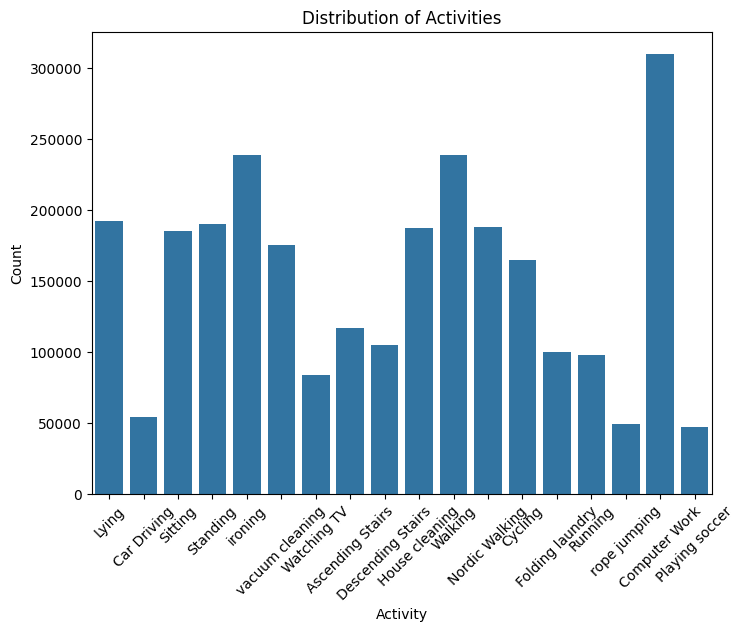

In [12]:
# Summary statistics of the accelerometer data
print(df.describe())

# Plotting the distribution of activities
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='activity_name')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.title('Distribution of Activities')
plt.xticks(rotation=45)
plt.show()


In [13]:
##  activity
def plot_session(sensor):
    plt.figure(figsize=(12, 8))

    for i, activity in enumerate(activities):
        
        all_recordings = df[df['activity_id'] == activity].copy()
        all_recordings = all_recordings.sort_values('timestamp')
        all_recordings['relative_idx'] = all_recordings.groupby('subject_id').cumcount()

        activity_avg = all_recordings.groupby('relative_idx')[sensor].mean()
        activity_std = all_recordings.groupby('relative_idx')[sensor].std()

        # Create a DataFrame with the results
        result_df = pd.DataFrame({'relative_idx': activity_avg.index, 'avg_value': activity_avg, 'std_value': activity_std})

        # Calculate upper and lower bounds for standard deviation
        result_df['upper'] = result_df['avg_value'] + result_df['std_value']
        result_df['lower'] = result_df['avg_value'] - result_df['std_value']

        # Create the plot
        plt.subplot(4, 5, i+1)
        plt.plot(result_df['relative_idx'], result_df['avg_value'], color='blue')
        plt.fill_between(result_df['relative_idx'], result_df['lower'], result_df['upper'], alpha=0.2, color='blue')

        # Customize the plot (optional)
        plt.xlabel('Relative idx')
        plt.ylabel(f'{sensor}')
        plt.title(f"{activities[activity]}")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

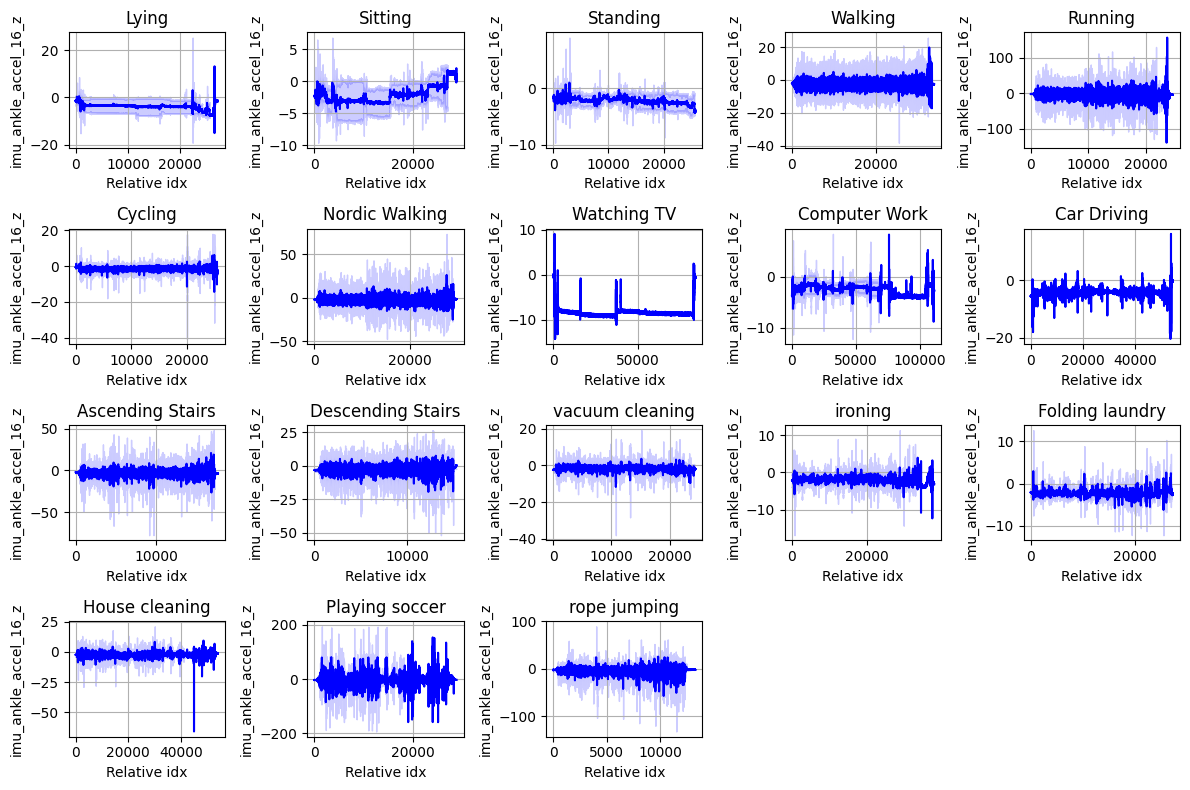

In [14]:
plot_session('imu_ankle_accel_16_z')

In [10]:
import numpy as np

df['magnitude_hand_16'] = np.sqrt(df['imu_hand_accel_16_x']**2 + df['imu_hand_accel_16_y']**2 + df['imu_hand_accel_16_z']**2)

df['magnitude_chest_16'] = np.sqrt(df['imu_chest_accel_16_x']**2 +df['imu_chest_accel_16_y']**2 +df['imu_chest_accel_16_z']**2)

df['magnitude_ankle_16'] = np.sqrt(df['imu_ankle_accel_16_x']**2 +df['imu_ankle_accel_16_y']**2 +df['imu_ankle_accel_16_z']**2)


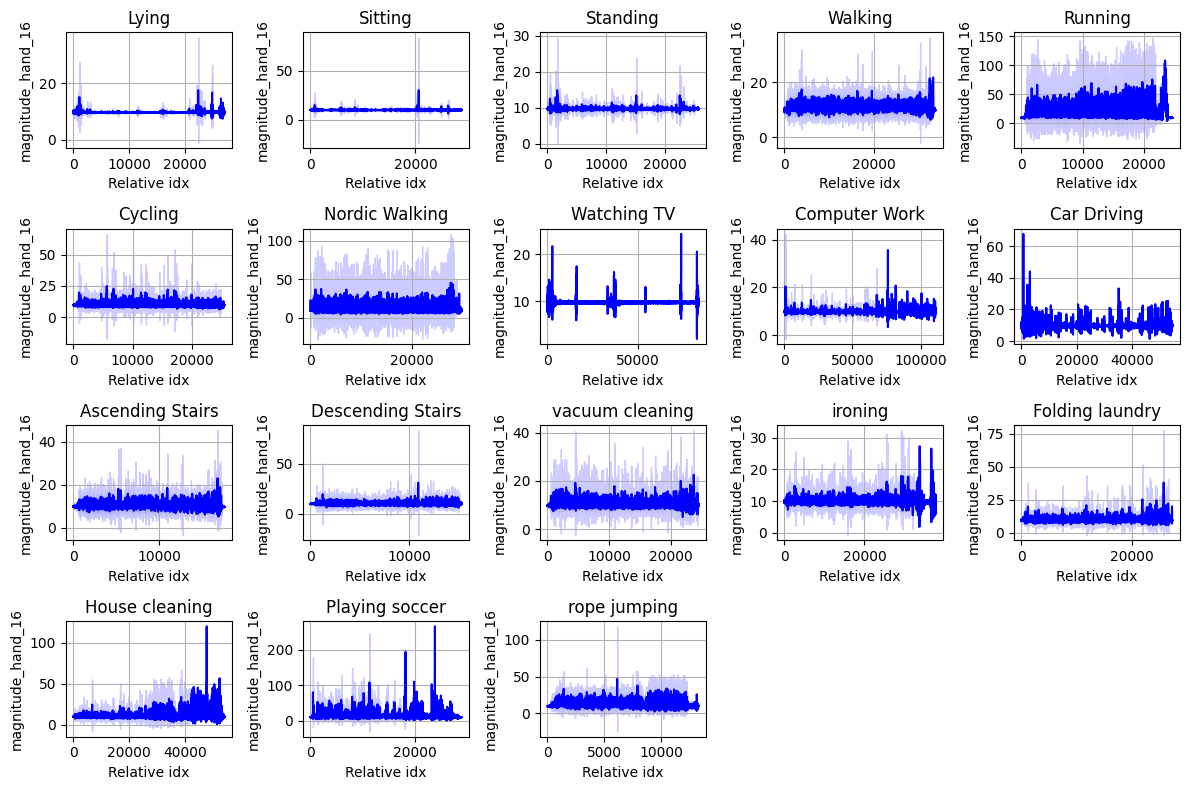

In [16]:
plot_session('magnitude_hand_16')

# Filtering gravity : 

In [13]:
from scipy.signal import butter, filtfilt
import numpy as np


def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

fs = 100 # sampling rate
cutoff_noise = 20.0  # to filter noise
cutoff_gravity = 0.3 # to estimate graviti


for pos in ['hand', 'ankle', 'chest']:
    for axis in ['x', 'y', 'z']:
        col = f'imu_{pos}_accel_16_{axis}'
        raw = df[col].values
        gravity = butter_lowpass_filter(raw, cutoff_gravity, fs)

        # acc_body
        body = raw - gravity

        df[f'{col}_filtered'] = body

    # norme du vecteur body
    df[f'magnitude_{pos}_filtered'] = np.sqrt(
        df[f'imu_{pos}_accel_16_x_filtered']**2 +
        df[f'imu_{pos}_accel_16_y_filtered']**2 +
        df[f'imu_{pos}_accel_16_z_filtered']**2
    )


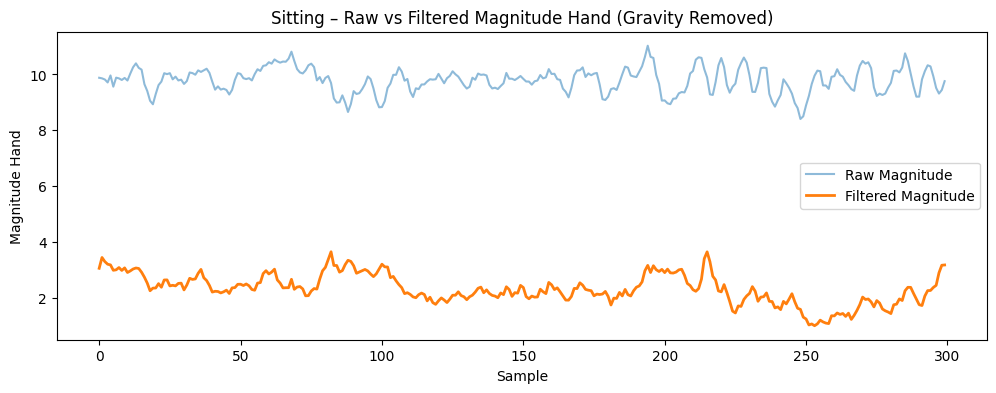

In [14]:
import matplotlib.pyplot as plt

df_sample = df[df['activity_name'] == 'Sitting'].head(300)

plt.figure(figsize=(12, 4))
plt.plot(df_sample['magnitude_hand_16'].values, label='Raw Magnitude', alpha=0.5)
plt.plot(df_sample['magnitude_hand_filtered'].values, label='Filtered Magnitude', linewidth=2)
plt.title('Sitting – Raw vs Filtered Magnitude Hand (Gravity Removed)')
plt.xlabel('Sample')
plt.ylabel('Magnitude Hand')
plt.legend()
plt.show()


In [15]:
df.head()

,timestamp,activity_id,imu_hand_temperature,imu_hand_accel_16_x,imu_hand_accel_16_y,imu_hand_accel_16_z,imu_hand_gyro_x,imu_hand_gyro_y,imu_hand_gyro_z,imu_hand_magnet_x,...,imu_ankle_accel_16_y_filtered,imu_ankle_accel_16_z_filtered,magnitude_ankle_filtered,imu_chest_accel_16_x_filtered,imu_chest_accel_16_y_filtered,imu_chest_accel_16_z_filtered,magnitude_chest_filtered,magnitude_hand_16,magnitude_chest_16,magnitude_ankle_16
2928,37.66,1,30.375,2.21530,8.27915,5.58753,-0.004750,0.037579,-0.011145,8.93200,...,-0.029690,0.035550,0.053643,-0.175205,0.014378,0.049603,0.182658,10.230952,9.791172,9.912723
2929,37.67,1,30.375,2.29196,7.67288,5.74467,-0.171710,0.025479,-0.009538,9.58300,...,-0.064538,-0.078858,0.102780,-0.098826,0.013426,0.050054,0.111589,9.855324,9.791979,9.879026
2930,37.68,1,30.375,2.29090,7.14240,5.82342,-0.238241,0.011214,0.000831,9.05516,...,-0.100273,-0.115675,0.153748,-0.029040,0.086217,-0.182212,0.203661,9.496016,9.907409,9.885166
2931,37.69,1,30.375,2.21800,7.14365,5.89930,-0.192912,0.019053,0.013374,9.92698,...,-0.023476,0.039437,0.065282,-0.062289,0.086661,-0.028913,0.110571,9.526437,9.879549,9.839102
2932,37.70,1,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,9.15626,...,-0.060256,0.042378,0.098980,0.053561,0.085847,0.010889,0.101770,9.751993,9.875840,9.956473


# Window Sliding

In [16]:
import pandas as pd
import numpy as np

def sliding_window(df, window_size, step, group_cols=['subject_id', 'activity_id'], time_col='timestamp'):

    sort_cols = group_cols + ([time_col] if time_col in df.columns else [])
    df = df.sort_values(sort_cols).reset_index(drop=True)

    windows = []
    window_id = 0

    for _, group in df.groupby(group_cols, sort=False):
        idx    = group.index.to_numpy()
        n      = len(group)

        for start in range(0, n - window_size + 1, step):
            windows.append(idx[start : start + window_size])
            window_id += 1

    if not windows:
        return pd.DataFrame()

    all_idx   = np.concatenate(windows)
    result    = df.loc[all_idx].reset_index(drop=True)

    result["window_id"] = np.repeat(np.arange(len(windows)), window_size)

    return result


WINDOW_SIZE = 512   # 100 Hz : 5.12 s
STEP        = 256   # 50% overlap

df_windowed = sliding_window(df, window_size=WINDOW_SIZE, step=STEP)

In [17]:
df_windowed['window_id'].unique()

array([    0,     1,     2, ..., 10486, 10487, 10488], shape=(10489,))

In [22]:
df_windowed.head()

,timestamp,activity_id,imu_hand_temperature,imu_hand_accel_16_x,imu_hand_accel_16_y,imu_hand_accel_16_z,imu_hand_gyro_x,imu_hand_gyro_y,imu_hand_gyro_z,imu_hand_magnet_x,...,magnitude_hand_filtered,imu_ankle_accel_16_x_filtered,imu_ankle_accel_16_y_filtered,imu_ankle_accel_16_z_filtered,magnitude_ankle_filtered,imu_chest_accel_16_x_filtered,imu_chest_accel_16_y_filtered,imu_chest_accel_16_z_filtered,magnitude_chest_filtered,window_id
0,37.66,1,30.375,2.21530,8.27915,5.58753,-0.004750,0.037579,-0.011145,8.93200,...,0.579830,-0.010406,0.013001,0.014605,0.022150,-0.152147,0.010958,0.044639,0.158939,0
1,37.67,1,30.375,2.29196,7.67288,5.74467,-0.171710,0.025479,-0.009538,9.58300,...,0.572561,-0.043690,-0.016244,-0.057842,0.074286,-0.078862,0.043989,-0.030616,0.095350,0
2,37.68,1,30.375,2.29090,7.14240,5.82342,-0.238241,0.011214,0.000831,9.05516,...,0.855986,-0.052597,-0.029195,-0.070212,0.092459,-0.022816,0.070328,-0.073086,0.103962,0
3,37.69,1,30.375,2.21800,7.14365,5.89930,-0.192912,0.019053,0.013374,9.92698,...,0.952111,-0.043219,-0.026986,-0.047339,0.069549,0.007602,0.077467,-0.078860,0.110806,0
4,37.70,1,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,9.15626,...,0.848379,-0.042259,-0.020211,-0.055898,0.072930,0.016384,0.059872,-0.067647,0.091811,0


In [18]:
print(f"Lignes: {df_windowed.shape[0]}")
print(f"Fenêtres uniques: {df_windowed['window_id'].nunique()}")
print(f"RAM utilisée: {df_windowed.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Lignes: 5370368
Fenêtres uniques: 10489
RAM utilisée: 2.94 GB


In [19]:
df_windowed['acc_hand_gyro_mag']  = np.sqrt(df_windowed['imu_hand_gyro_x']**2  + df_windowed['imu_hand_gyro_y']**2  + df_windowed['imu_hand_gyro_z']**2)
df_windowed['acc_chest_gyro_mag'] = np.sqrt(df_windowed['imu_chest_gyro_x']**2 + df_windowed['imu_chest_gyro_y']**2 + df_windowed['imu_chest_gyro_z']**2)
df_windowed['acc_ankle_gyro_mag'] = np.sqrt(df_windowed['imu_ankle_gyro_x']**2 + df_windowed['imu_ankle_gyro_y']**2 + df_windowed['imu_ankle_gyro_z']**2)
df_windowed = df_windowed.drop(columns=[col for col in df_windowed.columns if 'orientation' in col])
df_windowed = df_windowed.drop(columns=['imu_hand_accel_16_x', 'imu_hand_accel_16_y', 'imu_hand_accel_16_z','imu_chest_accel_16_x', 'imu_chest_accel_16_y',
       'imu_chest_accel_16_z', 'imu_ankle_accel_16_x','imu_ankle_accel_16_y', 'imu_ankle_accel_16_z','magnitude_hand_16', 'magnitude_chest_16',
       'magnitude_ankle_16'])

In [25]:
df_windowed.columns

Index(['timestamp', 'activity_id', 'imu_hand_temperature', 'imu_hand_gyro_x',
       'imu_hand_gyro_y', 'imu_hand_gyro_z', 'imu_hand_magnet_x',
       'imu_hand_magnet_y', 'imu_hand_magnet_z', 'imu_chest_temperature',
       'imu_chest_gyro_x', 'imu_chest_gyro_y', 'imu_chest_gyro_z',
       'imu_chest_magnet_x', 'imu_chest_magnet_y', 'imu_chest_magnet_z',
       'imu_ankle_temperature', 'imu_ankle_gyro_x', 'imu_ankle_gyro_y',
       'imu_ankle_gyro_z', 'imu_ankle_magnet_x', 'imu_ankle_magnet_y',
       'imu_ankle_magnet_z', 'subject_id', 'activity_name',
       'imu_hand_accel_16_x_filtered', 'imu_hand_accel_16_y_filtered',
       'imu_hand_accel_16_z_filtered', 'magnitude_hand_filtered',
       'imu_ankle_accel_16_x_filtered', 'imu_ankle_accel_16_y_filtered',
       'imu_ankle_accel_16_z_filtered', 'magnitude_ankle_filtered',
       'imu_chest_accel_16_x_filtered', 'imu_chest_accel_16_y_filtered',
       'imu_chest_accel_16_z_filtered', 'magnitude_chest_filtered',
       'window_id', 

In [20]:
rename_map = {
    'acc_hand_gyro_mag':  'imu_hand_gyro_mag',
    'acc_chest_gyro_mag': 'imu_chest_gyro_mag',
    'acc_ankle_gyro_mag': 'imu_ankle_gyro_mag',
}
df_windowed = df_windowed.rename(columns=rename_map)

feature_cols = {
    'hand': [
        'imu_hand_accel_16_x_filtered', 'imu_hand_accel_16_y_filtered', 
        'imu_hand_accel_16_z_filtered', 'magnitude_hand_filtered',
        'imu_hand_gyro_x', 'imu_hand_gyro_y', 
        'imu_hand_gyro_z', 'imu_hand_gyro_mag',
    ],
    'chest': [
        'imu_chest_accel_16_x_filtered', 'imu_chest_accel_16_y_filtered',
        'imu_chest_accel_16_z_filtered', 'magnitude_chest_filtered',
        'imu_chest_gyro_x', 'imu_chest_gyro_y',
        'imu_chest_gyro_z', 'imu_chest_gyro_mag',
    ],
    'ankle': [
        'imu_ankle_accel_16_x_filtered', 'imu_ankle_accel_16_y_filtered',
        'imu_ankle_accel_16_z_filtered', 'magnitude_ankle_filtered',
        'imu_ankle_gyro_x', 'imu_ankle_gyro_y',
        'imu_ankle_gyro_z', 'imu_ankle_gyro_mag',
    ],
}


In [21]:
df_windowed = df_windowed.drop(columns=['imu_hand_magnet_x' ,'imu_hand_magnet_y', 'imu_hand_magnet_z', 'imu_chest_magnet_x', 'imu_chest_magnet_y', 'imu_chest_magnet_z', 'imu_ankle_magnet_x', 'imu_ankle_magnet_y', 'imu_ankle_magnet_z'])

In [28]:
df_windowed.columns

Index(['timestamp', 'activity_id', 'imu_hand_temperature', 'imu_hand_gyro_x',
       'imu_hand_gyro_y', 'imu_hand_gyro_z', 'imu_chest_temperature',
       'imu_chest_gyro_x', 'imu_chest_gyro_y', 'imu_chest_gyro_z',
       'imu_ankle_temperature', 'imu_ankle_gyro_x', 'imu_ankle_gyro_y',
       'imu_ankle_gyro_z', 'subject_id', 'activity_name',
       'imu_hand_accel_16_x_filtered', 'imu_hand_accel_16_y_filtered',
       'imu_hand_accel_16_z_filtered', 'magnitude_hand_filtered',
       'imu_ankle_accel_16_x_filtered', 'imu_ankle_accel_16_y_filtered',
       'imu_ankle_accel_16_z_filtered', 'magnitude_ankle_filtered',
       'imu_chest_accel_16_x_filtered', 'imu_chest_accel_16_y_filtered',
       'imu_chest_accel_16_z_filtered', 'magnitude_chest_filtered',
       'window_id', 'imu_hand_gyro_mag', 'imu_chest_gyro_mag',
       'imu_ankle_gyro_mag'],
      dtype='str')

In [23]:
from scipy import stats

def extract_features(window: np.ndarray, feature_cols: list) -> dict:
    """
    Extract statistical features from a single window.
    window shape: (window_size, n_features)
    """

    feats = {}
    
    for i, col in enumerate(feature_cols):
        x = window[:, i]
        
        # Time domain
        feats[f'{col}_mean']     = np.mean(x)
        feats[f'{col}_std']      = np.std(x)
        feats[f'{col}_min']      = np.min(x)
        feats[f'{col}_max']      = np.max(x)
        feats[f'{col}_range']    = np.max(x) - np.min(x)
        feats[f'{col}_median']   = np.median(x)
        feats[f'{col}_iqr']      = stats.iqr(x)
        feats[f'{col}_kurtosis'] = stats.kurtosis(x)
        feats[f'{col}_rms']      = np.sqrt(np.mean(x**2))
        feats[f'{col}_energy']   = np.sum(x**2) / len(x)
        feats[f'{col}_mad']      = np.mean(np.abs(x - np.mean(x)))  # mean absolute deviation
        feats[f'{col}_zc']       = np.sum(np.diff(np.sign(x)) != 0)  # zero crossings
        
        fft_vals  = np.abs(np.fft.rfft(x))
        freqs     = np.fft.rfftfreq(len(x), d=1/100)  # 100 Hz
        
        feats[f'{col}_fft_mean']       = np.mean(fft_vals)
        feats[f'{col}_fft_std']        = np.std(fft_vals)
        feats[f'{col}_fft_energy']     = np.sum(fft_vals**2) / len(fft_vals)
        feats[f'{col}_dominant_freq']  = freqs[np.argmax(fft_vals[1:]) + 1]  # skip DC
        feats[f'{col}_spectral_entropy'] = stats.entropy(fft_vals / fft_vals.sum() + 1e-10)
        
    return feats


def build_feature_matrix(df_windowed, feature_cols, meta_cols=None):
    """
    Extract features for all windows.
    Returns X (feature matrix) and y (labels).
    """
    if meta_cols is None:
        meta_cols = ['subject_id', 'activity_id', 'timestamp', 'window_id']

    n_windows  = df_windowed['window_id'].nunique()
    n_features = len(feature_cols)

    # 3D array (n_windows, window_size, n_features)
    X_raw = df_windowed[feature_cols].to_numpy().reshape(n_windows, -1, n_features)

    # Labels
    y = (
        df_windowed
        .groupby('window_id')['activity_id']
        .agg(lambda x: x.mode()[0])
        .to_numpy()
    )

    # Subject par fenêtre (utile pour LOSO cross-validation)
    subjects = (
        df_windowed
        .groupby('window_id')['subject_id']
        .first()
        .to_numpy()
    )

    # Extract features
    rows = []
    for i in range(n_windows):
        feats          = extract_features(X_raw[i], feature_cols)
        feats['label'] = y[i]
        feats['subject_id'] = subjects[i]
        rows.append(feats)

    df_features = pd.DataFrame(rows)

    return df_features


meta_cols    = ['subject_id', 'activity_id', 'timestamp', 'window_id', 'activity_name']

feature_cols = [c for c in df_windowed.columns if c not in meta_cols]

df_features = build_feature_matrix(df_windowed, feature_cols)

print(f"Shape : {df_features.shape}")  # (10489, n_features_extraites + 2)
print(f"RAM   : {df_features.memory_usage(deep=True).sum() / 1e6:.1f} MB")

/tmp/ipykernel_37078/243235604.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f'{col}_kurtosis'] = stats.kurtosis(x)


Shape : (10489, 461)
RAM   : 38.7 MB


In [25]:
columns = df_features.columns
print(columns.to_list())

['imu_hand_temperature_mean', 'imu_hand_temperature_std', 'imu_hand_temperature_min', 'imu_hand_temperature_max', 'imu_hand_temperature_range', 'imu_hand_temperature_median', 'imu_hand_temperature_iqr', 'imu_hand_temperature_kurtosis', 'imu_hand_temperature_rms', 'imu_hand_temperature_energy', 'imu_hand_temperature_mad', 'imu_hand_temperature_zc', 'imu_hand_temperature_fft_mean', 'imu_hand_temperature_fft_std', 'imu_hand_temperature_fft_energy', 'imu_hand_temperature_dominant_freq', 'imu_hand_temperature_spectral_entropy', 'imu_hand_gyro_x_mean', 'imu_hand_gyro_x_std', 'imu_hand_gyro_x_min', 'imu_hand_gyro_x_max', 'imu_hand_gyro_x_range', 'imu_hand_gyro_x_median', 'imu_hand_gyro_x_iqr', 'imu_hand_gyro_x_kurtosis', 'imu_hand_gyro_x_rms', 'imu_hand_gyro_x_energy', 'imu_hand_gyro_x_mad', 'imu_hand_gyro_x_zc', 'imu_hand_gyro_x_fft_mean', 'imu_hand_gyro_x_fft_std', 'imu_hand_gyro_x_fft_energy', 'imu_hand_gyro_x_dominant_freq', 'imu_hand_gyro_x_spectral_entropy', 'imu_hand_gyro_y_mean', 'imu

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

X = df_features.drop(columns=['label', 'subject_id'])
y = df_features['label']


colonnes_nan = X.columns[X.isna().any()].tolist()
X = X.drop(columns=colonnes_nan)


In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=-1) # visualisation 2D
X_tsne = tsne.fit_transform(X_scaled)


tsne_df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'activity': y.values
})

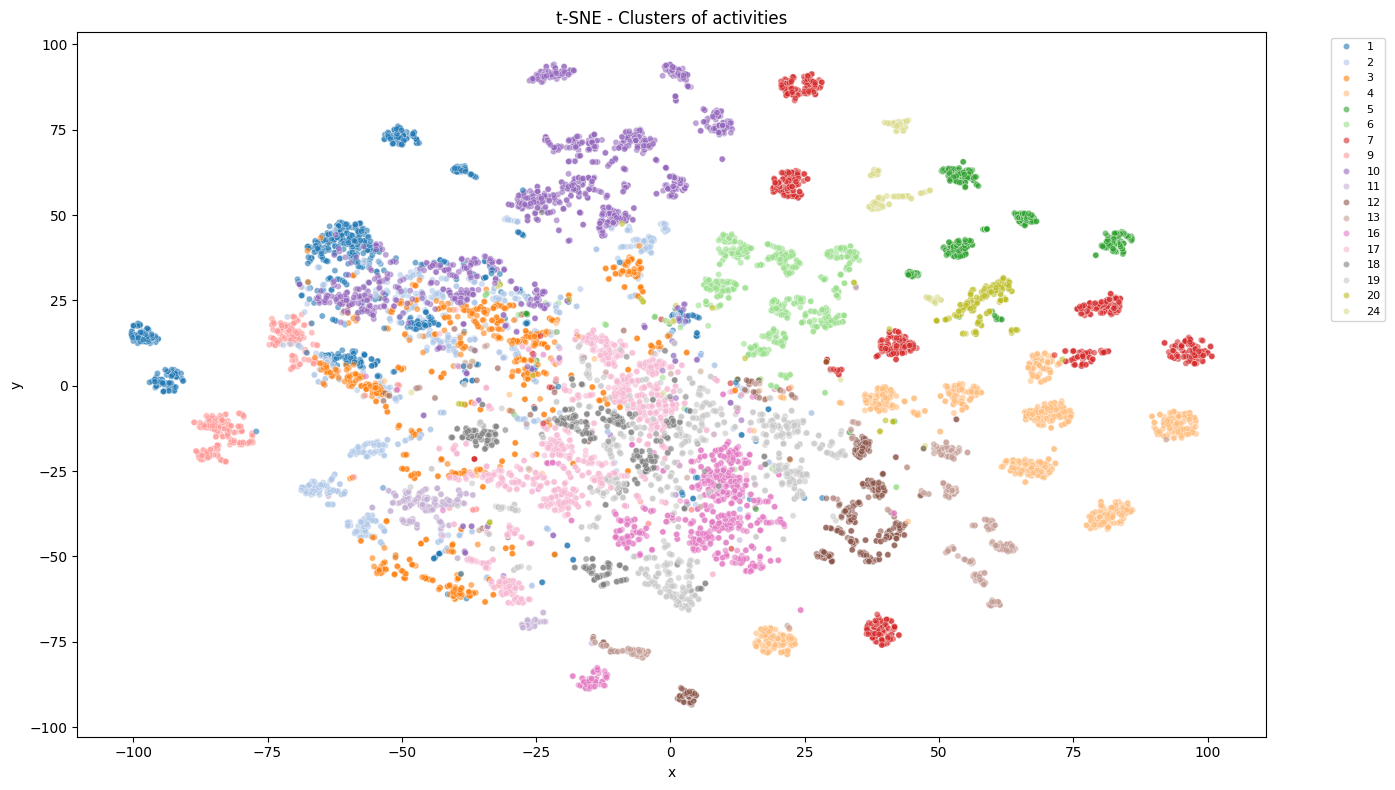

In [37]:
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=tsne_df,
    x='x', y='y',
    hue='activity',
    palette='tab20',
    alpha=0.6,
    s=20
)
plt.title('t-SNE - Clusters of activities')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [38]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV


param_grid_lr = {
    'C':       [0.01, 0.1, 1, 10],
    'solver':  ['lbfgs'],
    'max_iter': [5000],
    'class_weight': ['balanced']
} # 8 combinations

param_grid_svm = {
    'C':            [1, 10, 100],
    'gamma':        [0.001, 0.01, 0.1],
    'kernel':       ['rbf'],
    'class_weight': ['balanced']
} # 9 combinations

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt'],
    'max_depth':    [None, 10],
    'class_weight': ['balanced']
} # 18 combinations


def train_and_classify(X, y, groups):

    logo = LeaveOneGroupOut()
    n_groups = logo.get_n_splits(X, y, groups=groups)

    lr_predictions, svm_predictions, rf_predictions, true_labels = [], [], [], []
    best_params = {'lr': [], 'svm': [], 'rf': []}


    for train_idx, test_idx in tqdm(logo.split(X, y, groups=groups), total=n_groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Scaler on the train
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)


        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        # LR
        # gs_lr = GridSearchCV(
        #     LogisticRegression(),
        #     param_grid_lr,
        #     cv=inner_cv,
        #     scoring='f1_macro',
        #     n_jobs=-1
        # )
        # gs_lr.fit(X_train_sc, y_train)
        # best_params['lr'].append(gs_lr.best_params_)
        # lr_predictions.extend(gs_lr.best_estimator_.predict(X_test_sc))

        # SVM (needs scaling)
        # gs_svm = GridSearchCV(
        #     SVC(),
        #     param_grid_svm,
        #     cv=inner_cv,
        #     scoring='f1_macro',
        #     n_jobs=-1
        # )
        # gs_svm.fit(X_train_sc, y_train)
        # best_params['svm'].append(gs_svm.best_params_)
        # svm_predictions.extend(gs_svm.best_estimator_.predict(X_test_sc))

        # RF
        gs_rf = GridSearchCV(
            RandomForestClassifier(n_jobs=-1),
            param_grid_rf,
            cv=inner_cv,
            scoring='f1_macro',
            n_jobs=-1
        )
        gs_rf.fit(X_train, y_train)
        best_params['rf'].append(gs_rf.best_params_)
        rf_predictions.extend(gs_rf.best_estimator_.predict(X_test))

        true_labels.extend(y_test)

    # print("=== LR ===")
    # print(classification_report(true_labels, lr_predictions))

    # print("=== SVM ===")
    # print(classification_report(true_labels, svm_predictions))

    print("=== Random Forest ===")
    print(classification_report(true_labels, rf_predictions))

    return (
        # classification_report(true_labels, lr_predictions, output_dict=True),
        # classification_report(true_labels, svm_predictions,  output_dict=True),
        classification_report(true_labels, rf_predictions,  output_dict=True),
        best_params
    )

In [39]:
groups = df_features['subject_id'].to_numpy()
X_np   = X.to_numpy()
y_np   = y.to_numpy()

out = train_and_classify(X_np, y_np, groups)
print(len(out))

100%|██████████| 9/9 [04:32<00:00, 30.31s/it]

=== Random Forest ===
              precision    recall  f1-score   support

           1       0.51      0.57      0.54       742
           2       0.25      0.26      0.26       711
           3       0.36      0.47      0.40       730
           4       0.93      0.95      0.94       921
           5       0.78      0.85      0.82       376
           6       0.97      0.91      0.94       634
           7       0.97      0.89      0.93       725
           9       0.00      0.00      0.00       325
          10       0.52      0.47      0.49      1205
          11       0.00      0.00      0.00       211
          12       0.89      0.91      0.90       445
          13       0.87      0.86      0.86       398
          16       0.59      0.67      0.63       673
          17       0.36      0.41      0.38       921
          18       0.01      0.01      0.01       384
          19       0.34      0.32      0.33       724
          20       0.48      0.21      0.29       180
     

RF Accuracy: 0.5677




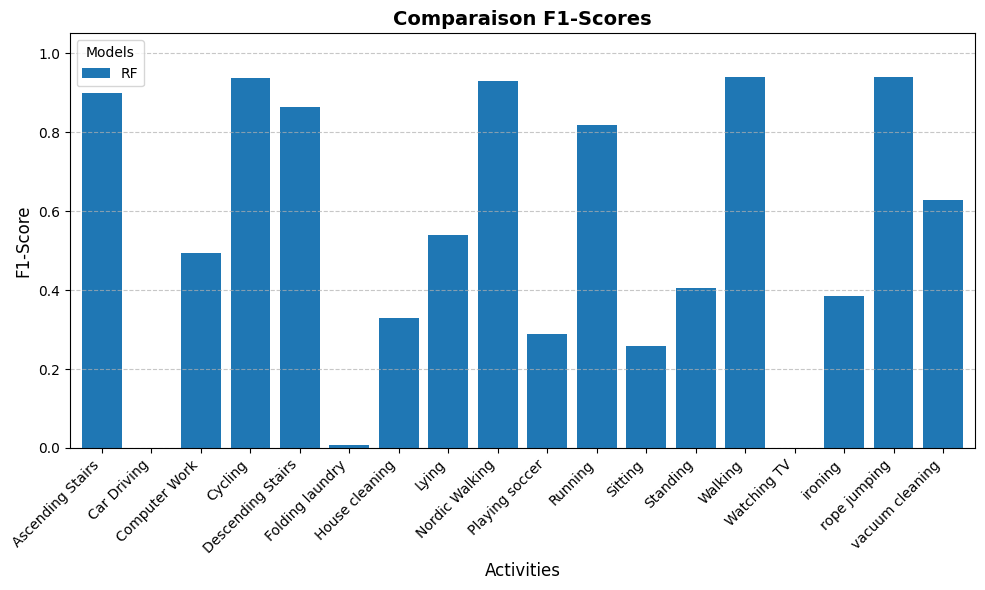

In [41]:
models = {#'SVM' : out[1],
#           'LR' : out[0],
          'RF' : out[0]}

data_for_plot = []
for model_name, rep in models.items():
    print(f"{model_name} Accuracy: {rep['accuracy']:.4f}")
    
    for act in activities:
        act_name = activities[act] 
        f1 = rep[str(act)]['f1-score']
        data_for_plot.append({
            'Model': model_name,
            'Activity': act_name,
            'F1-Score': f1
        })

print('\n')

df_scores = pd.DataFrame(data_for_plot)

df_pivot = df_scores.pivot(index='Activity', columns='Model', values='F1-Score')

plt.figure(figsize=(10, 6))
df_pivot.plot(kind='bar', ax=plt.gca(), width=0.8)

plt.title("Comparaison F1-Scores", fontsize=14, fontweight='bold')
plt.xlabel("Activities", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Models")

plt.tight_layout()
plt.show()

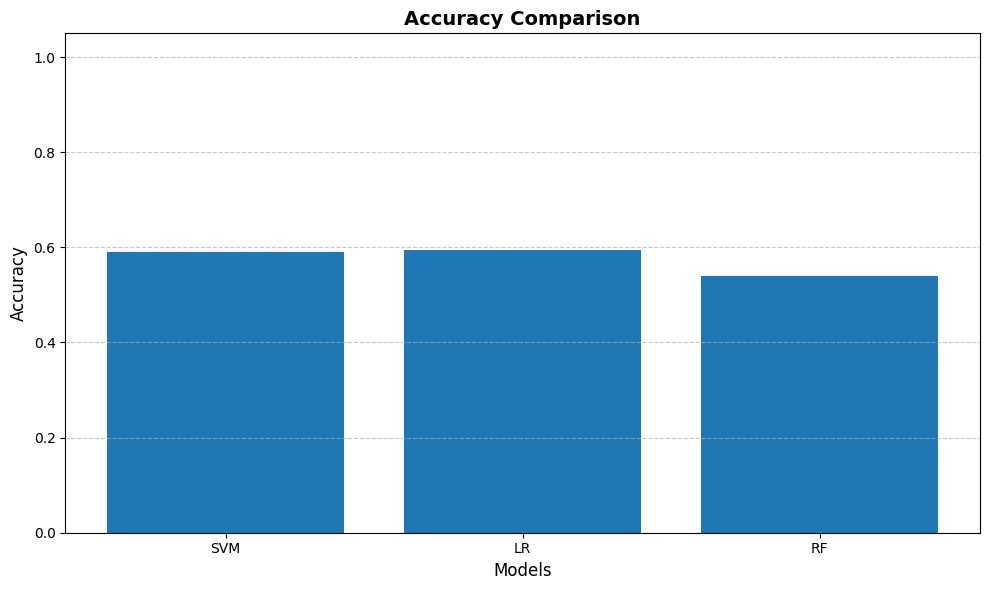

In [88]:
data_for_plot = []
for model_name, rep in models.items():
    acc = rep['accuracy']
    data_for_plot.append({
        'Model': model_name,
        'Accuracy': acc
        })

print('\n')

df_scores = pd.DataFrame(data_for_plot)

plt.figure(figsize=(10, 6))
plt.bar(df_scores['Model'], df_scores['Accuracy'])

plt.title("Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()